<a href="https://colab.research.google.com/github/Lukanov73/Monty-Hall-Maritime-Analysis/blob/main/Monty_Hall_SAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilistic Analysis of the Monty Hall Paradox in Maritime Navigation

## 1. Problem Formulation
The Monty Hall problem is applied here to a maritime Search and Rescue (SAR) scenario to determine the optimal decision-making strategy based on updated information.
### 1.1 The Maritime Search Scenario
A vessel is reported missing in a search area divided into three sectors: **Sector A, Sector B, and Sector C**. Initially, each sector has a 1/3 probability of containing the vessel.

1. **Initial Choice:** A Search and Rescue (SAR) aircraft is dispatched to **Sector A**.
2. **New Information:** While the aircraft is in transit, satellite intelligence confirms with 100% certainty that the vessel is **NOT in Sector C**.
3. **The Dilemma:** The Rescue Coordination Center (RCC) commander must decide: stay in Sector A or divert to Sector B?
### 1.2 Assumptions and Limitations
To ensure the validity of the probabilistic model, the following assumptions are made:
* **Stationary Target:** We assume the vessel does not move between the sectors during the initial search phase.
* **Uniform Probability:** Initially, each sector (A, B, and C) has an equal 1/3 probability.
* **Reliable Intelligence:** The satellite information ruling out Sector C is considered 100% accurate.
* **Scope:** This model specifically analyzes a 3-sector scenario; increasing the number of sectors would require a modified Bayesian approach.
## 2. Mathematical Proof (Bayesian Inference)
We want to find the probability that the vessel is in Sector B, given that we know it is not in Sector C ($I_C$).

According to Bayes' Theorem:
$$P(B|I_C) = \frac{P(I_C|B)P(B)}{P(I_C)}$$

* **Initial probability:** $P(B) = 1/3$
* **Conditional probability:** $P(I_C|B) = 1$ (If the vessel is in B, the intelligence MUST report it is not in C)
* **Total probability of the evidence:** $P(I_C) = 1/2$

**Result:** $P(B|I_C) = 2/3$. The probability doubles if we switch our search to Sector B.

### 3. Monte Carlo Simulation
Running 10,000 trials to empirically test the mathematical proof.

Stay in Sector A wins: 3279
Switch to Sector B wins: 6721


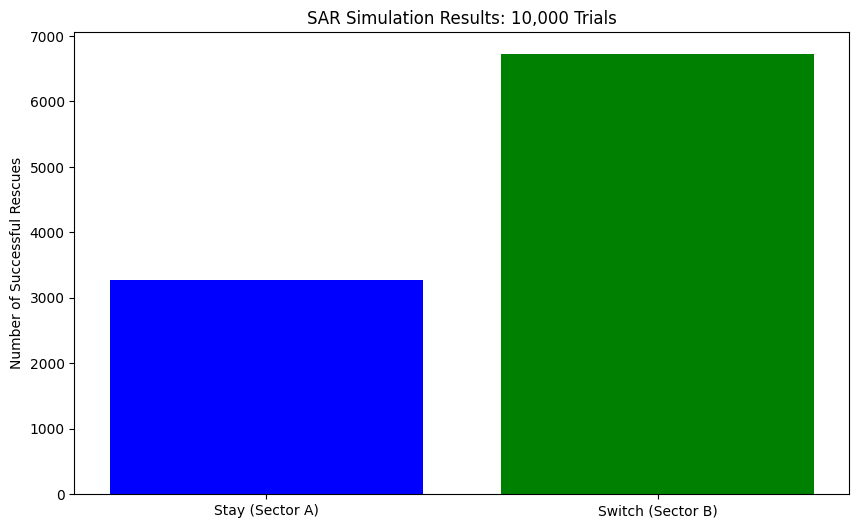

In [4]:
# Step 1: Import libraries for simulation and plotting
import random
import matplotlib.pyplot as plt

# Step 2: Define the Search and Rescue simulation function
def simulate_sar(trials=10000):
    stay_wins = 0
    switch_wins = 0

    for _ in range(trials):
        # The vessel is randomly hidden in one of the 3 sectors
        vessel_location = random.randint(0, 2)
        # Initial search starts in Sector A
        initial_choice = 0

        # Satellite rules out a sector with no vessel
        remaining_sectors = [s for s in [0, 1, 2] if s != initial_choice and s != vessel_location]
        ruled_out = random.choice(remaining_sectors)

        # Determine the alternative sector to switch to
        switch_choice = [s for s in [0, 1, 2] if s != initial_choice and s != ruled_out][0]

        if initial_choice == vessel_location:
            stay_wins += 1
        if switch_choice == vessel_location:
            switch_wins += 1

    return stay_wins, switch_wins

# Step 3: Run the simulation and store results
stay, switch = simulate_sar()
print(f'Stay in Sector A wins: {stay}')
print(f'Switch to Sector B wins: {switch}')

# Step 4: Create a visual comparison of the strategies
strategies = ['Stay (Sector A)', 'Switch (Sector B)']
wins = [stay, switch]

plt.figure(figsize=(10, 6))
plt.bar(strategies, wins, color=['blue', 'green'])
plt.ylabel('Number of Successful Rescues')
plt.title('SAR Simulation Results: 10,000 Trials')
plt.show()

## 4. Summary of Results

After running the simulation 10,000 times, the results are very clear:

* **Staying with Sector A:** Led to a successful rescue only about **33%** of the time.
* **Switching to Sector B:** Led to a successful rescue about **67%** of the time.

**Conclusion for the SAR Mission:**
The data shows that switching sectors is not just a guess — it is a statistically better move.By using the new information from the satellite (which ruled out one area),the rescue team effectively **doubles their chances** of finding the vessel.This proves that in search operations,updating your strategy based on new facts is the most effective way to save lives.

## 5. References

* [1] "Monty Hall Problem", Wikipedia.
* [2] "Bayesian Inference", Stanford Encyclopedia of Philosophy.
* [3] "IAMSAR Manual: International Aeronautical and Maritime Search and Rescue Manual", International Maritime Organization (IMO).